# Fitting Gaia epoch astrometry with `gaiamock`

This notebook shows how to generate mock Gaia epoch astrometry for an astrometric binary and fit it with `gaiamock`. It also compares the available nonlinear optimizers:

- `periodogram_multistart`: the default optimizer. It uses a linear circular-orbit periodogram to choose promising periods, then does an eccentric scan and C Nelder-Mead polish. The default C settings use the faster `grid_70pct_nm_loose` configuration.
- `periodogram_multistart_full`: the same periodogram-based strategy, but with a denser period grid and tighter Nelder-Mead tolerances.
- `multistart`: a deterministic C grid/multistart optimizer that does not use the periodogram preselection.
- `annealing`: the original adaptive simulated annealing optimizer described in the gaiamock paper.

## Setup

Before using the C-backed orbit fitters, make sure `kepler_solve_astrometry.c` has been compiled in the same directory as `gaiamock.py`, producing `kepler_solve_astrometry.so`.

On many Linux systems this is enough:

```bash
gcc -shared -o kepler_solve_astrometry.so kepler_solve_astrometry.c -lgsl -lgslcblas -lm -fPIC
```

On a Mac with Homebrew GSL, you may need explicit include/library paths (see example in the header of kepler_solve_astrometry.c)

The mock-data generator used below expects the precomputed `healpix_scans/` directory to be present in this repository.

In [1]:
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt

import gaiamock

GAIAMOCK_DIR = Path(gaiamock.__file__).resolve().parent
c_funcs = gaiamock.read_in_C_functions()

print(f"Using gaiamock from: {Path(gaiamock.__file__).resolve()}")
print(f"Using C library from: {GAIAMOCK_DIR / 'kepler_solve_astrometry.so'}")

HEALPIX_DIR = GAIAMOCK_DIR / "healpix_scans"
if not HEALPIX_DIR.exists():
    raise FileNotFoundError(f"Missing {HEALPIX_DIR}. The mock-data generator needs healpix_scans/ in the gaiamock repo.")
print(f"Using healpix scans from: {HEALPIX_DIR}")


Using gaiamock from: /Users/kareem/bin/gaiamock/gaiamock.py
Using C library from: /Users/kareem/bin/gaiamock/kepler_solve_astrometry.so
Using healpix scans from: /Users/kareem/bin/gaiamock/healpix_scans


## Generate mock Gaia epoch astrometry

`gaiamock.predict_astrometry_binary_in_terms_of_a0` generates Gaia-like one-dimensional along-scan astrometry for a binary. It uses the precomputed Gaia scanning law samples in `healpix_scans/`, then adds noise using the approximate Gaia along-scan uncertainty model.

The returned arrays are exactly the inputs expected by the fitters:

- `t_ast_yr`: epoch times in years relative to the Gaia reference epoch.
- `psi`: scan angles in radians.
- `plx_factor`: along-scan parallax factors.
- `ast_obs`: along-scan astrometric measurements in mas.
- `ast_err`: uncertainties in mas.

In [2]:
# Reproducibility for the mocked noise and random epoch rejection.
np.random.seed(11)

mock_truth = {
    "ra": 280.0,                 # deg
    "dec": 35.0,                # deg
    "parallax": 0.55,           # mas
    "pmra": 0.03,               # mas/yr
    "pmdec": -0.02,             # mas/yr
    "period": 255.0,            # days
    "Tp": 2.0,                  # days relative to the Gaia reference epoch convention used internally
    "ecc": 0.08,
    "omega": 1.1,               # big Omega, radians
    "inc": np.deg2rad(67.0),    # radians
    "w": 0.8,                   # little omega, radians
    "a0_mas": 1.20,             # photocenter semimajor axis, mas
    "phot_g_mean_mag": 16.0,
    "data_release": "dr4",
}

# This is the gaiamock mock-data generator. It returns epoch astrometry arrays.
t_ast_yr, psi, plx_factor, ast_obs, ast_err = gaiamock.predict_astrometry_binary_in_terms_of_a0(
    c_funcs=c_funcs,
    **mock_truth,
)

# Sort by time and remove any non-finite values, just as you would for real data.
good = np.isfinite(t_ast_yr) & np.isfinite(psi) & np.isfinite(plx_factor) & np.isfinite(ast_obs) & np.isfinite(ast_err) & (ast_err > 0)
order = np.argsort(t_ast_yr[good])
t_ast_yr, psi, plx_factor, ast_obs, ast_err = [arr[good][order] for arr in (t_ast_yr, psi, plx_factor, ast_obs, ast_err)]

print(f"N_epoch = {len(t_ast_yr)}")
print("Mock truth:")
for key in ("period", "Tp", "ecc", "a0_mas", "parallax", "phot_g_mean_mag"):
    print(f"  {key:16s} {mock_truth[key]}")

N_epoch = 88
Mock truth:
  period           255.0
  Tp               2.0
  ecc              0.08
  a0_mas           1.2
  parallax         0.55
  phot_g_mean_mag  16.0


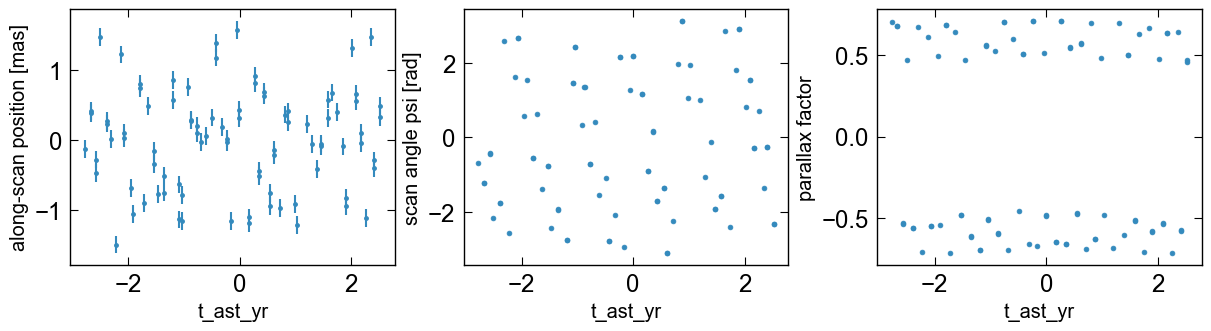

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)
axes[0].errorbar(t_ast_yr, ast_obs, yerr=ast_err, fmt=".", ms=5)
axes[0].set_xlabel("t_ast_yr")
axes[0].set_ylabel("along-scan position [mas]")
axes[1].scatter(t_ast_yr, psi, s=12)
axes[1].set_xlabel("t_ast_yr")
axes[1].set_ylabel("scan angle psi [rad]")
axes[2].scatter(t_ast_yr, plx_factor, s=12)
axes[2].set_xlabel("t_ast_yr")
axes[2].set_ylabel("parallax factor")
plt.show()

## First: fit a 5-parameter single-star model

`check_ruwe` fits the usual five astrometric parameters and returns a RUWE-like goodness of fit. A large value is a sign that a single-star model is not adequate.

In [4]:
ruwe_5p, mu_5p, sigma_mu_5p = gaiamock.check_ruwe(
    t_ast_yr=t_ast_yr,
    psi=psi,
    plx_factor=plx_factor,
    ast_obs=ast_obs,
    ast_err=ast_err,
    binned=True,
)

single_star_names = ["ra_off", "pmra", "dec_off", "pmdec", "plx"]
print(f"5p RUWE-like statistic: {ruwe_5p:.3f}")
for name, value, err in zip(single_star_names, mu_5p, sigma_mu_5p):
    print(f"{name:7s} = {value:9.4f} +/- {err:.4f}")

5p RUWE-like statistic: 2.010
ra_off  =   -0.1380 +/- 0.0375
pmra    =    0.0340 +/- 0.0246
dec_off =   -0.0713 +/- 0.0408
pmdec   =    0.0336 +/- 0.0257
plx     =    0.5031 +/- 0.0464


## Compare the nonlinear orbit optimizers directly

The orbital model is linear in the Thiele-Innes parameters for fixed nonlinear parameters `(P, phi_p, ecc)`. The optimizer only searches over those three nonlinear parameters; for each trial point, the C code solves the linear least-squares problem.

The direct optimizer call returns only `(P, phi_p, ecc)`. We then call `get_astrometric_chi2` to recover the chi2 and linear parameters.

If you omit the `optimizer` argument, `gaiamock` now uses `periodogram_multistart`, i.e. the fast periodogram multistart path. Use `optimizer="periodogram_multistart_full"` when you want the denser original periodogram grid and tighter local-polish tolerances.

In [5]:
def run_direct_optimizer(label, optimizer=None, reject_outlier=True, p_min=10.0, p_max=1e4):
    kwargs = {}
    if optimizer is not None:
        kwargs["optimizer"] = optimizer

    start = time.monotonic()
    theta = gaiamock.fit_orbital_solution_nonlinear(
        t_ast_yr,
        psi,
        plx_factor,
        ast_obs,
        ast_err,
        c_funcs,
        L=np.array([p_min, 0.0, 0.0]),
        U=np.array([p_max, 2 * np.pi, 0.99]),
        reject_outlier=reject_outlier,
        **kwargs,
    )
    seconds = time.monotonic() - start
    chi2, mu_linear = gaiamock.get_astrometric_chi2(
        t_ast_yr,
        psi,
        plx_factor,
        ast_obs,
        ast_err,
        P=theta[0],
        phi_p=theta[1],
        ecc=theta[2],
        c_funcs=c_funcs,
        reject_outlier=reject_outlier,
    )
    return {
        "optimizer": label,
        "optimizer_arg": optimizer,
        "period": float(theta[0]),
        "phi_p": float(theta[1]),
        "ecc": float(theta[2]),
        "chi2": float(chi2),
        "seconds": seconds,
        "mu_linear": mu_linear,
    }


optimizer_runs = [
    ("default / periodogram_multistart", None),
    ("periodogram_multistart_full", "periodogram_multistart_full"),
    ("multistart", "multistart"),
    ("annealing", "annealing"),
]

direct_results = []
for label, optimizer in optimizer_runs:
    try:
        result = run_direct_optimizer(label, optimizer=optimizer, reject_outlier=True)
        direct_results.append(result)
        print(
            f"{label:34s} P={result['period']:10.4f} d  "
            f"e={result['ecc']:.4f}  chi2={result['chi2']:.3f}  "
            f"time={result['seconds']:.3f} s"
        )
    except Exception as exc:
        print(f"{label:34s} failed: {type(exc).__name__}: {exc}")

default / periodogram_multistart   P=  255.7648 d  e=0.0334  chi2=56.327  time=0.306 s
periodogram_multistart_full        P=  255.7648 d  e=0.0334  chi2=56.327  time=0.478 s
multistart                         P=  255.7648 d  e=0.0334  chi2=56.327  time=0.353 s
annealing                          P=  255.7648 d  e=0.0334  chi2=56.327  time=1.245 s


### What is different between the optimizers?

- `periodogram_multistart` is the default. It uses a linear circular-orbit periodogram to score each period once. For circular orbits, phase can be absorbed into the linear Thiele-Innes coefficients, so this avoids redundant phase scans during the first period-selection step. It then does an eccentric scan and local C Nelder-Mead polish. The default compiled C settings use the faster `grid_70pct_nm_loose` configuration.
- `periodogram_multistart_full` uses the same periodogram strategy, but keeps the original denser period grids, more start points, and tighter Nelder-Mead tolerances. It is slower, but useful for spot checks or difficult systems.
- `multistart` is deterministic. It scans a broad period grid plus a denser short-period grid, tries multiple phases and eccentricities for the best periods, then polishes many starts with a C Nelder-Mead optimizer.
- `annealing` is stochastic/adaptive. It can work well, but two runs can take different paths and occasionally miss a narrow basin.

For large production searches, I recommend you simply to omit `optimizer` or pass `optimizer="periodogram_multistart"`.

## Run the full astrometric cascade

`fit_full_astrometric_cascade` is the higher-level interface. It first checks whether a 5-parameter model is good enough. If not, it can check acceleration models. If those are skipped or do not pass the cuts, it fits the full 12-parameter orbital model.

For binary searches, common choices are `skip_acceleration=True` and `reject_outlier=True`. The nonlinear optimizer defaults to `periodogram_multistart`, so the example below does not pass an optimizer argument explicitly.

In [6]:
result = gaiamock.fit_full_astrometric_cascade(
    t_ast_yr=t_ast_yr,
    psi=psi,
    plx_factor=plx_factor,
    ast_obs=ast_obs,
    ast_err=ast_err,
    c_funcs=c_funcs,
    verbose=True,
    show_residuals=False,
    binned=True,
    ruwe_min=1.25,
    skip_acceleration=True,
    reject_outlier=True,
    P_min=10,
)

result_names = [
    "plx", "sig_parallax", "A", "sig_A", "B", "sig_B", "F", "sig_F", "G", "sig_G",
    "period", "sig_period", "phi_p", "sig_phi_p", "ecc", "sig_ecc", "inc_deg",
    "a0_mas", "sigma_a0_mas", "N_visibility_periods", "N_obs", "F2", "ruwe",
]

print("\nCascade result:")
for name, value in zip(result_names, result):
    print(f"{name:20s} {value}")

found best-fit nonlinear parameters: [2.55764848e+02 2.48975951e+00 3.34440362e-02]
goodness_of_fit (F2) is low enough to pass DR3 cuts! F2: -0.5
a0_over_err is high enough to pass DR3 cuts! a0_over_err: 43.3
parallax over error is NOT high enough to pass DR3 cuts! parallax_over_error: 22.5
eccentricity error is low enough to pass DR3 cuts! ecc_error: 0.04

Cascade result:
plx                  0.5295745555141483
sig_parallax         0.023582300944559372
A                    -0.4990823538103183
sig_A                0.6081776181175342
B                    -1.1169330074877626
sig_B                0.14009849878870612
F                    0.5007846588814345
sig_F                0.6088808001517144
G                    -0.11072993550094151
sig_G                1.3548517060743508
period               255.7648479359444
sig_period           0.3608254817089399
phi_p                2.4897595109312305
sig_phi_p            1.211015645709247
ecc                  0.03344403615830476
sig_ecc           

## Compare the 5p and 12p residuals

A useful first diagnostic is to compare the residuals from a single-star fit with the residuals from the orbital fit. `gaiamock.plot_residuals` does this directly: it solves the best 5-parameter model, solves the best 12-parameter model at the supplied nonlinear orbit parameters, and plots both residual time series.

Using best direct optimizer result: annealing
P = 255.76485 d, phi_p = 2.48976, e = 0.0334
single star chi2: 2208.76
binary star chi2: 62.28


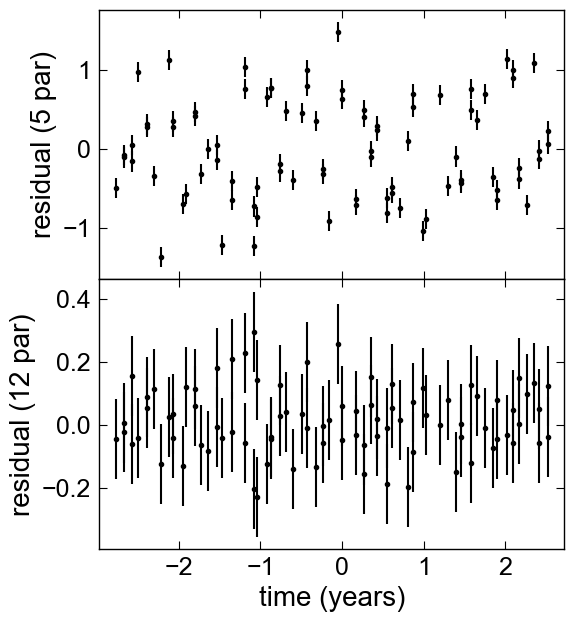

In [7]:
best = min(direct_results, key=lambda row: row["chi2"])
period, phi_p, ecc = best["period"], best["phi_p"], best["ecc"]

print(f"Using best direct optimizer result: {best['optimizer']}")
print(f"P = {period:.5f} d, phi_p = {phi_p:.5f}, e = {ecc:.4f}")

gaiamock.plot_residuals(
    t_ast_yr=t_ast_yr,
    psi=psi,
    plx_factor=plx_factor,
    ast_obs=ast_obs,
    ast_err=ast_err,
    theta_array=np.array([period, phi_p, ecc]),
    c_funcs=c_funcs,
)
plt.show()

The same comparison can be useful to make manually, because it gives direct access to the residual arrays and chi2 values for further diagnostics.

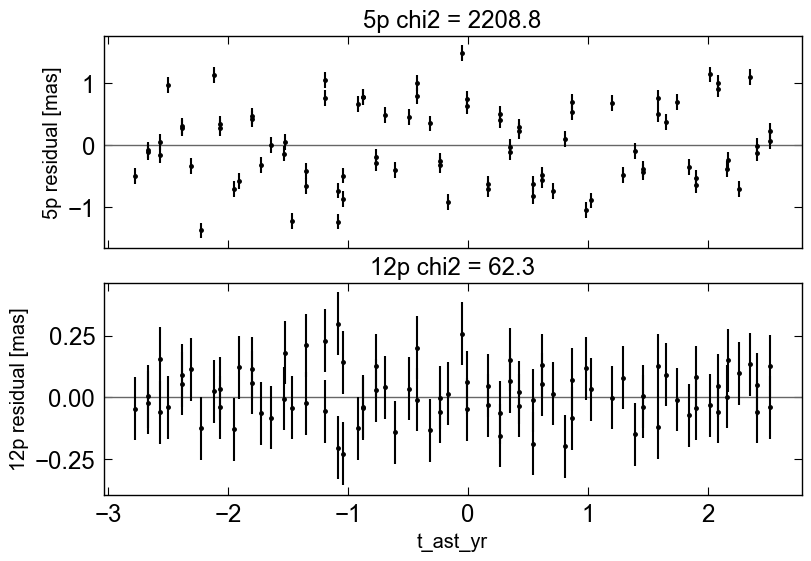

In [8]:
def fit_5p_model(t_ast_yr, psi, plx_factor, ast_obs, ast_err):
    design = np.vstack([
        np.sin(psi),
        t_ast_yr * np.sin(psi),
        np.cos(psi),
        t_ast_yr * np.cos(psi),
        plx_factor,
    ]).T
    weights = 1.0 / ast_err**2
    lhs = design.T @ (weights[:, None] * design)
    rhs = design.T @ (weights * ast_obs)
    mu = np.linalg.solve(lhs, rhs)
    model = design @ mu
    return model, mu

model_5p, mu_5p_manual = fit_5p_model(t_ast_yr, psi, plx_factor, ast_obs, ast_err)
model_12p = gaiamock.get_residuals_12par_solution(
    t_ast_yr=t_ast_yr,
    psi=psi,
    plx_factor=plx_factor,
    ast_obs=ast_obs,
    ast_err=ast_err,
    theta_array=np.array([period, phi_p, ecc]),
    c_funcs=c_funcs,
)

resid_5p = (ast_obs - model_5p) / ast_err
resid_12p = (ast_obs - model_12p) / ast_err
chi2_5p = np.sum(resid_5p**2)
chi2_12p = np.sum(resid_12p**2)

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, constrained_layout=True)
axes[0].axhline(0, color="0.4", lw=1)
axes[0].errorbar(t_ast_yr, ast_obs - model_5p, yerr=ast_err, fmt="k.", ms=5)
axes[0].set_ylabel("5p residual [mas]")
axes[0].set_title(f"5p chi2 = {chi2_5p:.1f}")
axes[1].axhline(0, color="0.4", lw=1)
axes[1].errorbar(t_ast_yr, ast_obs - model_12p, yerr=ast_err, fmt="k.", ms=5)
axes[1].set_xlabel("t_ast_yr")
axes[1].set_ylabel("12p residual [mas]")
axes[1].set_title(f"12p chi2 = {chi2_12p:.1f}")
plt.show()

## Plot the fitted orbit

The Thiele-Innes coefficients describe the projected sky-plane photocenter orbit. `plot_2d_orbit_and_residuals` shows that orbit together with the along-scan residual displacements.


a0 = 1.229 mas
Omega = 63.6 deg, omega = 185.8 deg, inc = 66.0 deg


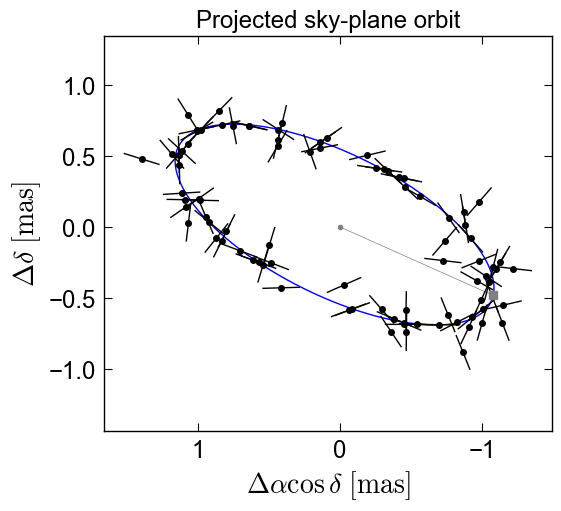

In [9]:
chi2, mu_linear = gaiamock.get_astrometric_chi2(
    t_ast_yr=t_ast_yr,
    psi=psi,
    plx_factor=plx_factor,
    ast_obs=ast_obs,
    ast_err=ast_err,
    P=period,
    phi_p=phi_p,
    ecc=ecc,
    c_funcs=c_funcs,
    reject_outlier=True,
)
ra_off, pmra, dec_off, pmdec, plx, B, G, A, F = mu_linear
Tp = phi_p * period / (2 * np.pi)

a0_mas, Omega, w_fit, inc = gaiamock.get_Campbell_elements(A=A, B=B, F=F, G=G)
print(f"a0 = {a0_mas:.3f} mas")
print(f"Omega = {np.degrees(Omega):.1f} deg, omega = {np.degrees(w_fit):.1f} deg, inc = {np.degrees(inc):.1f} deg")

fig, ax = plt.subplots(figsize=(5.5, 5.0), constrained_layout=True)
gaiamock.plot_2d_orbit_and_residuals(
    t_ast_yr=t_ast_yr,
    psi=psi,
    plx_factor=plx_factor,
    ast_obs=ast_obs,
    ast_err=ast_err,
    period=period,
    ecc=ecc,
    Tp=Tp,
    delta_ra=ra_off,
    delta_dec=dec_off,
    parallax=plx,
    pmra=pmra,
    pmdec=pmdec,
    data_release=mock_truth["data_release"],
    A=A,
    B=B,
    F=F,
    G=G,
    c_funcs=c_funcs,
    ax=ax,
)
ax.set_title("Projected sky-plane orbit")
ax.axis("equal")
plt.show()


## Practical recommendations

- For most production binary searches, omit `optimizer` or use `optimizer="periodogram_multistart"`. This is now the default and uses the faster `grid_70pct_nm_loose` C settings.
- Use `optimizer="periodogram_multistart_full"` for spot checks, difficult cases, or validation runs where you want the original denser periodogram grid and tighter Nelder-Mead polish.
- Use `optimizer="multistart"` as a deterministic non-periodogram fallback. Performance is very similar to periodogram_multistart, but it's typically a bit slower. 
- Use `optimizer="annealing"` mainly for backward compatibility or comparisons to older results.
- Set `reject_outlier=True` only if you want the objective itself to ignore the single worst epoch during each likelihood call. This changes the fit objective, so compare like with like.
- For high-throughput runs, pass a preloaded `c_funcs = gaiamock.read_in_C_functions()` rather than repeatedly loading the shared library.